“Traditional transfer learning can only leverage a single source domain at a time, because data are siloed.
In contrast, our FL-based pretraining aggregates knowledge from multiple clients without sharing raw data, which leads to a stronger initialization for the target client.

In [191]:
# ============================================================
# Cell 1 — Imports & global setup
# ============================================================

import os
from pathlib import Path
import random

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

import h5py
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cuda


In [192]:
# ============================================================
# Cell 2 — User configuration
# ============================================================

LABEL_KEY = "Y_Y"

TRAIN_FILE_PATHS = [
    "gfli1_impedance_dataset.mat",
    "gfli2_impedance_dataset.mat",
    "gfli3_impedance_dataset.mat",
    "gfli4_impedance_dataset.mat",
    "gfli5_impedance_dataset.mat",
    "gfli6_impedance_dataset.mat",
    "gfli7_impedance_dataset.mat",
    "gfli8_impedance_dataset.mat",
    "gfli9_impedance_dataset.mat",
]

TEST_FILE_PATHS = [
    "gfli1_test_impedance_dataset.mat",
    "gfli2_test_impedance_dataset.mat",
    "gfli3_test_impedance_dataset.mat",
    "gfli4_test_impedance_dataset.mat",
    "gfli5_test_impedance_dataset.mat",
    "gfli6_test_impedance_dataset.mat",
    "gfli7_test_impedance_dataset.mat",
    "gfli8_test_impedance_dataset.mat",
    "gfli9_test_impedance_dataset.mat",
]

# Scenario: New client TL with FL backbone
TARGET_IBR = "gfli1"  # change if needed

# Training hyperparams
BATCH_SIZE = 512
EPOCHS_FT_TARGET = 500

# FedAvg pretrain
ROUNDS_PRE_FL = 100
LOCAL_EPOCHS_FL = 5
LR_INIT_FL = 1e-3
BATCH_SIZE_FL = 512

print(f"#TRAIN files: {len(TRAIN_FILE_PATHS)}, #TEST files: {len(TEST_FILE_PATHS)}")
print("TARGET_IBR:", TARGET_IBR)

#TRAIN files: 9, #TEST files: 9
TARGET_IBR: gfli1


In [193]:
# ============================================================
# Cell 3 — IO helpers (.mat / .h5)
# ============================================================

def _fix_shape(arr, expected_cols=None):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    if expected_cols is not None:
        if arr.shape[1] != expected_cols and arr.shape[0] == expected_cols:
            arr = arr.T
    return arr


def _extract_from_h5(f, label_key="Y_Y"):
    def get_node(g, key):
        return g[key] if key in g else None

    g = get_node(f, "Dataset") or get_node(f, "dataset")

    if g is not None:
        X = _fix_shape(g["X"][()], expected_cols=4)
        Ysrc = g[label_key] if label_key in g else g.get("Y_Y")
        if Ysrc is None:
            raise KeyError("Neither label_key nor 'Y_Y' found under /Dataset")
        Y = _fix_shape(Ysrc[()], expected_cols=8)
        return X, Y

    Xnode = get_node(f, "X")
    Ynode = get_node(f, label_key) or get_node(f, "Y_Y")
    if Xnode is None or Ynode is None:
        raise KeyError("Could not find X and Y in HDF5 file.")

    X = _fix_shape(Xnode[()], expected_cols=4)
    Y = _fix_shape(Ynode[()], expected_cols=8)
    return X, Y


def _extract_from_mat(d, label_key="Y_Y"):
    d2 = {k: v for k, v in d.items() if not k.startswith("__")}

    if "Dataset" in d2:
        G = d2["Dataset"]
        if hasattr(G, "dtype") and G.dtype.names:
            fields = G.dtype.names

            def get_field(name):
                if name in fields:
                    val = np.array(G[name]).squeeze()
                    return val
                return None

            X_raw = get_field("X")
            if X_raw is None:
                raise KeyError("Field 'X' not found in Dataset struct.")
            X = _fix_shape(X_raw, expected_cols=4)

            Yraw = get_field(label_key) or get_field("Y_Y")
            if Yraw is None:
                raise KeyError("Neither label_key nor 'Y_Y' found in Dataset struct.")
            Y = _fix_shape(Yraw, expected_cols=8)
            return X, Y

    X = d2.get("X", None)
    Y = d2.get(label_key, None) or d2.get("Y_Y", None)
    if X is None or Y is None:
        raise KeyError("Could not find X and Y in MAT file (top-level).")

    X = _fix_shape(X, expected_cols=4)
    Y = _fix_shape(Y, expected_cols=8)
    return X, Y


def load_dataset_mat(path, label_key="Y_Y"):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    lower = path.name.lower()
    family = "GFMI" if "gfmi" in lower else "GFLI"
    is_test = "_test_" in lower
    ibr_full = path.stem.lower()
    ibr_prefix = ibr_full.split("_")[0]  # "gfli1"

    # Try HDF5 first
    try:
        with h5py.File(path, "r") as f:
            X, Y = _extract_from_h5(f, label_key=label_key)
    except Exception as e_h5:
        try:
            d = loadmat(str(path))
            X, Y = _extract_from_mat(d, label_key=label_key)
        except Exception as e_mat:
            raise Exception(f"Error loading {path}: h5py-> {e_h5}; loadmat-> {e_mat}")

    return {
        "X": X,
        "Y": Y,
        "family": family,
        "ibr": ibr_prefix,
        "is_test": is_test,
        "path": str(path),
    }

In [194]:
# ============================================================
# Cell 4 — Load TRAIN / TEST (raw) and build per-IBR dict
# ============================================================

loaded_tr, loaded_te = [], []

for fp in TRAIN_FILE_PATHS:
    d = load_dataset_mat(fp, LABEL_KEY)
    if d["family"] == "GFLI":
        loaded_tr.append(d)
        print(f"[TRAIN] {d['ibr']}  X:{d['X'].shape} Y:{d['Y'].shape}")

for fp in TEST_FILE_PATHS:
    d = load_dataset_mat(fp, LABEL_KEY)
    if d["family"] == "GFLI":
        loaded_te.append(d)
        print(f"[TEST ] {d['ibr']}  X:{d['X'].shape} Y:{d['Y'].shape}")

train_raw = {d["ibr"]: d for d in loaded_tr}
test_raw  = {d["ibr"]: d for d in loaded_te}

ALL_IBRS = sorted(train_raw.keys())
if TARGET_IBR not in train_raw or TARGET_IBR not in test_raw:
    raise RuntimeError(f"Missing target train/test for {TARGET_IBR}. Available train: {ALL_IBRS}, test: {sorted(test_raw.keys())}")

SOURCE_IBRS = [ibr for ibr in ALL_IBRS if ibr != TARGET_IBR]
print("ALL_IBRS   :", ALL_IBRS)
print("SOURCE_IBRS:", SOURCE_IBRS)
print("TARGET_IBR :", TARGET_IBR)

[TRAIN] gfli1  X:(390, 4) Y:(390, 8)
[TRAIN] gfli2  X:(330, 4) Y:(330, 8)
[TRAIN] gfli3  X:(330, 4) Y:(330, 8)
[TRAIN] gfli4  X:(100, 4) Y:(100, 8)
[TRAIN] gfli5  X:(330, 4) Y:(330, 8)
[TRAIN] gfli6  X:(220, 4) Y:(220, 8)
[TRAIN] gfli7  X:(140, 4) Y:(140, 8)
[TRAIN] gfli8  X:(180, 4) Y:(180, 8)
[TRAIN] gfli9  X:(40, 4) Y:(40, 8)
[TEST ] gfli1  X:(780, 4) Y:(780, 8)
[TEST ] gfli2  X:(660, 4) Y:(660, 8)
[TEST ] gfli3  X:(660, 4) Y:(660, 8)
[TEST ] gfli4  X:(200, 4) Y:(200, 8)
[TEST ] gfli5  X:(660, 4) Y:(660, 8)
[TEST ] gfli6  X:(440, 4) Y:(440, 8)
[TEST ] gfli7  X:(280, 4) Y:(280, 8)
[TEST ] gfli8  X:(342, 4) Y:(342, 8)
[TEST ] gfli9  X:(80, 4) Y:(80, 8)
ALL_IBRS   : ['gfli1', 'gfli2', 'gfli3', 'gfli4', 'gfli5', 'gfli6', 'gfli7', 'gfli8', 'gfli9']
SOURCE_IBRS: ['gfli2', 'gfli3', 'gfli4', 'gfli5', 'gfli6', 'gfli7', 'gfli8', 'gfli9']
TARGET_IBR : gfli1


In [195]:
# ============================================================
# Cell 5 — Scaling (fit on SOURCE only) + TensorDatasets (CPU)
# ============================================================

# Fit scalers on SOURCE only (avoid leakage)
X_src_all = np.vstack([train_raw[ibr]["X"] for ibr in SOURCE_IBRS])
Y_src_all = np.vstack([train_raw[ibr]["Y"] for ibr in SOURCE_IBRS])

X_scaler = StandardScaler().fit(X_src_all)
Y_scaler = StandardScaler().fit(Y_src_all)

input_dim  = X_src_all.shape[1]  # expect 4
output_dim = Y_src_all.shape[1]  # expect 8
print("Input dim:", input_dim, "| Output dim:", output_dim)

def to_tensor_dataset(X_np, Y_np):
    Xs = X_scaler.transform(X_np).astype(np.float32)
    Ys = Y_scaler.transform(Y_np).astype(np.float32)
    X_t = torch.from_numpy(Xs)   # keep CPU
    Y_t = torch.from_numpy(Ys)   # keep CPU
    return TensorDataset(X_t, Y_t)

train_sets = {ibr: to_tensor_dataset(train_raw[ibr]["X"], train_raw[ibr]["Y"]) for ibr in ALL_IBRS}
test_sets  = {ibr: to_tensor_dataset(test_raw[ibr]["X"],  test_raw[ibr]["Y"])  for ibr in sorted(test_raw.keys())}

train_target = train_sets[TARGET_IBR]
test_target  = test_sets[TARGET_IBR]

print(f"#train target ({TARGET_IBR}): {len(train_target)}")
print(f"#test  target ({TARGET_IBR}): {len(test_target)}")

Input dim: 4 | Output dim: 8
#train target (gfli1): 390
#test  target (gfli1): 780


In [196]:
# ============================================================
# Cell 6 — Model definitions
# ============================================================

HIDDEN_GFLI = 32

class Trunk(nn.Module):
    def __init__(self, in_dim=4, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

class Head(nn.Module):
    def __init__(self, hidden_dim=64, out_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.ReLU(),
            nn.Linear(16, out_dim),
        )
    def forward(self, h):
        return self.net(h)

class FullModel(nn.Module):
    def __init__(self, trunk: Trunk, head: Head):
        super().__init__()
        self.trunk = trunk
        self.head  = head
    def forward(self, x):
        return self.head(self.trunk(x))

def make_model(in_dim=input_dim, hidden_dim=HIDDEN_GFLI, out_dim=output_dim):
    trunk = Trunk(in_dim=in_dim, hidden_dim=hidden_dim)
    head  = Head(hidden_dim=hidden_dim, out_dim=out_dim)
    return FullModel(trunk, head).to(device)

In [197]:
# ============================================================
# Cell 7 — Metrics + fine-tune helpers (MSE consistent!)
# ============================================================

def compute_mse_on_dataset(model, dataset, batch_size=512):
    """
    MSE = sum_{i,j} e_ij^2 / (N * D)
    """
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    crit = nn.MSELoss(reduction="sum")

    total_sum, total_n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            total_sum += crit(pred, yb).item()
            total_n += xb.size(0)

    return total_sum / (total_n * output_dim)


def get_model_state_dict_cpu(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def load_state_dict_cpu_to_model(model, state_dict_cpu):
    model.load_state_dict(state_dict_cpu, strict=True)


def fine_tune(
    base_state_dict_cpu,          # can be None for scratch
    train_ds,
    test_ds,
    epochs=100,
    batch_size=512,
    lr=1e-3,
    tag="FineTune",
):
    model = make_model()
    if base_state_dict_cpu is not None:
        load_state_dict_cpu_to_model(model, base_state_dict_cpu)

    # zero-shot / init test mse
    mse0 = compute_mse_on_dataset(model, test_ds, batch_size=batch_size)
    print(f"[{tag}] Init/Zero-shot test MSE = {mse0:.4e}")

    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit_sum = nn.MSELoss(reduction="sum")

    hist_train, hist_test = [], []

    for ep in range(1, epochs + 1):
        model.train()
        sum_sq, n_total = 0.0, 0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = crit_sum(pred, yb)   # sum of squared error over batch*D
            loss.backward()
            opt.step()

            sum_sq += loss.item()
            n_total += xb.size(0)

        train_mse = sum_sq / (n_total * output_dim)
        test_mse  = compute_mse_on_dataset(model, test_ds, batch_size=batch_size)

        hist_train.append(train_mse)
        hist_test.append(test_mse)

        print(f"[{tag}] Epoch {ep:03d} | train MSE={train_mse:.4e} | test MSE={test_mse:.4e}")

    return model, mse0, hist_train, hist_test

In [198]:
# ============================================================
# Cell 8 — FedAvg pretrain (SOURCE only)
# ============================================================

def get_lr_for_round(r, rounds, lr_init=1e-3, factor=0.1):
    d1 = int(np.ceil(0.70 * rounds))
    d2 = int(np.ceil(0.85 * rounds))
    if r <= d1:
        return lr_init
    elif r <= d2:
        return lr_init * factor
    else:
        return lr_init * factor * 0.5


def fedavg_states(model_states_cpu, sizes):
    total = float(sum(sizes))
    avg = {}
    keys = model_states_cpu[0].keys()
    for k in keys:
        acc = torch.zeros_like(model_states_cpu[0][k])
        for sd, n in zip(model_states_cpu, sizes):
            acc += (n / total) * sd[k]
        avg[k] = acc
    return avg


def train_one_client_local(client_ds, global_state_cpu, epochs=1, batch_size=256, lr=1e-3):
    model = make_model()
    load_state_dict_cpu_to_model(model, global_state_cpu)
    model.train()

    loader = DataLoader(client_ds, batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()  # mean is fine for optimization

    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = crit(pred, yb)
            loss.backward()
            opt.step()

    return get_model_state_dict_cpu(model)


def fedavg_pretrain(train_sets_dict, ibr_list, rounds=100, local_epochs=5, batch_size=512, tag="FedAvg"):
    print(f"\n===== {tag} pretrain on SOURCE IBRs: {ibr_list} =====")

    clients = []
    for ibr in ibr_list:
        ds = train_sets_dict[ibr]
        n = ds.tensors[0].shape[0]
        clients.append((ibr, ds, n))

    global_model = make_model()
    global_state = get_model_state_dict_cpu(global_model)

    for r in range(1, rounds + 1):
        lr_round = get_lr_for_round(r, rounds, lr_init=LR_INIT_FL, factor=0.1)
        states, sizes = [], []
        for ibr, ds, n in clients:
            new_state = train_one_client_local(
                client_ds=ds,
                global_state_cpu=global_state,
                epochs=local_epochs,
                batch_size=batch_size,
                lr=lr_round,
            )
            states.append(new_state)
            sizes.append(n)

        global_state = fedavg_states(states, sizes)

        if r == 1 or r % 10 == 0 or r == rounds:
            print(f"[{tag}] Round {r:03d}/{rounds} done | lr={lr_round:.2e}")

    return global_state


In [199]:
# ============================================================
# Cell 9 — Run: FL pretrain -> fine-tune target, plus Scratch baseline
# ============================================================

# 1) FL backbone (FedAvg on SOURCE)
fl_global_state = fedavg_pretrain(
    train_sets_dict=train_sets,
    ibr_list=SOURCE_IBRS,
    rounds=ROUNDS_PRE_FL,
    local_epochs=LOCAL_EPOCHS_FL,
    batch_size=BATCH_SIZE_FL,
    tag="FedAvg-Pretrain",
)

# 2) Fine-tune on TARGET from FL backbone
model_ft_fl, zero_fl, tr_ft_fl, te_ft_fl = fine_tune(
    base_state_dict_cpu=fl_global_state,
    train_ds=train_target,
    test_ds=test_target,
    epochs=EPOCHS_FT_TARGET,
    batch_size=BATCH_SIZE,
    lr=1e-3,
    tag=f"TL-FL->Target ({TARGET_IBR})",
)

# 3) Scratch baseline: random init then train on TARGET
model_ft_scratch, zero_sc, tr_ft_sc, te_ft_sc = fine_tune(
    base_state_dict_cpu=None,
    train_ds=train_target,
    test_ds=test_target,
    epochs=EPOCHS_FT_TARGET,
    batch_size=BATCH_SIZE,
    lr=1e-3,
    tag=f"Scratch->Target ({TARGET_IBR})",
)



===== FedAvg-Pretrain pretrain on SOURCE IBRs: ['gfli2', 'gfli3', 'gfli4', 'gfli5', 'gfli6', 'gfli7', 'gfli8', 'gfli9'] =====
[FedAvg-Pretrain] Round 001/100 done | lr=1.00e-03
[FedAvg-Pretrain] Round 010/100 done | lr=1.00e-03
[FedAvg-Pretrain] Round 020/100 done | lr=1.00e-03
[FedAvg-Pretrain] Round 030/100 done | lr=1.00e-03
[FedAvg-Pretrain] Round 040/100 done | lr=1.00e-03
[FedAvg-Pretrain] Round 050/100 done | lr=1.00e-03
[FedAvg-Pretrain] Round 060/100 done | lr=1.00e-03
[FedAvg-Pretrain] Round 070/100 done | lr=1.00e-03
[FedAvg-Pretrain] Round 080/100 done | lr=1.00e-04
[FedAvg-Pretrain] Round 090/100 done | lr=5.00e-05
[FedAvg-Pretrain] Round 100/100 done | lr=5.00e-05
[TL-FL->Target (gfli1)] Init/Zero-shot test MSE = 4.2587e-01
[TL-FL->Target (gfli1)] Epoch 001 | train MSE=3.8658e-01 | test MSE=4.1897e-01
[TL-FL->Target (gfli1)] Epoch 002 | train MSE=3.8010e-01 | test MSE=4.1265e-01
[TL-FL->Target (gfli1)] Epoch 003 | train MSE=3.7413e-01 | test MSE=4.0686e-01
[TL-FL->Target

C:\Users\ACER\AppData\Local\Temp\ipykernel_24716\4254930265.py:44: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = {"FL-TL": float(np.trapz(fl_curve, epochs_axis)),
C:\Users\ACER\AppData\Local\Temp\ipykernel_24716\4254930265.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "Scratch": float(np.trapz(sc_curve, epochs_axis))}


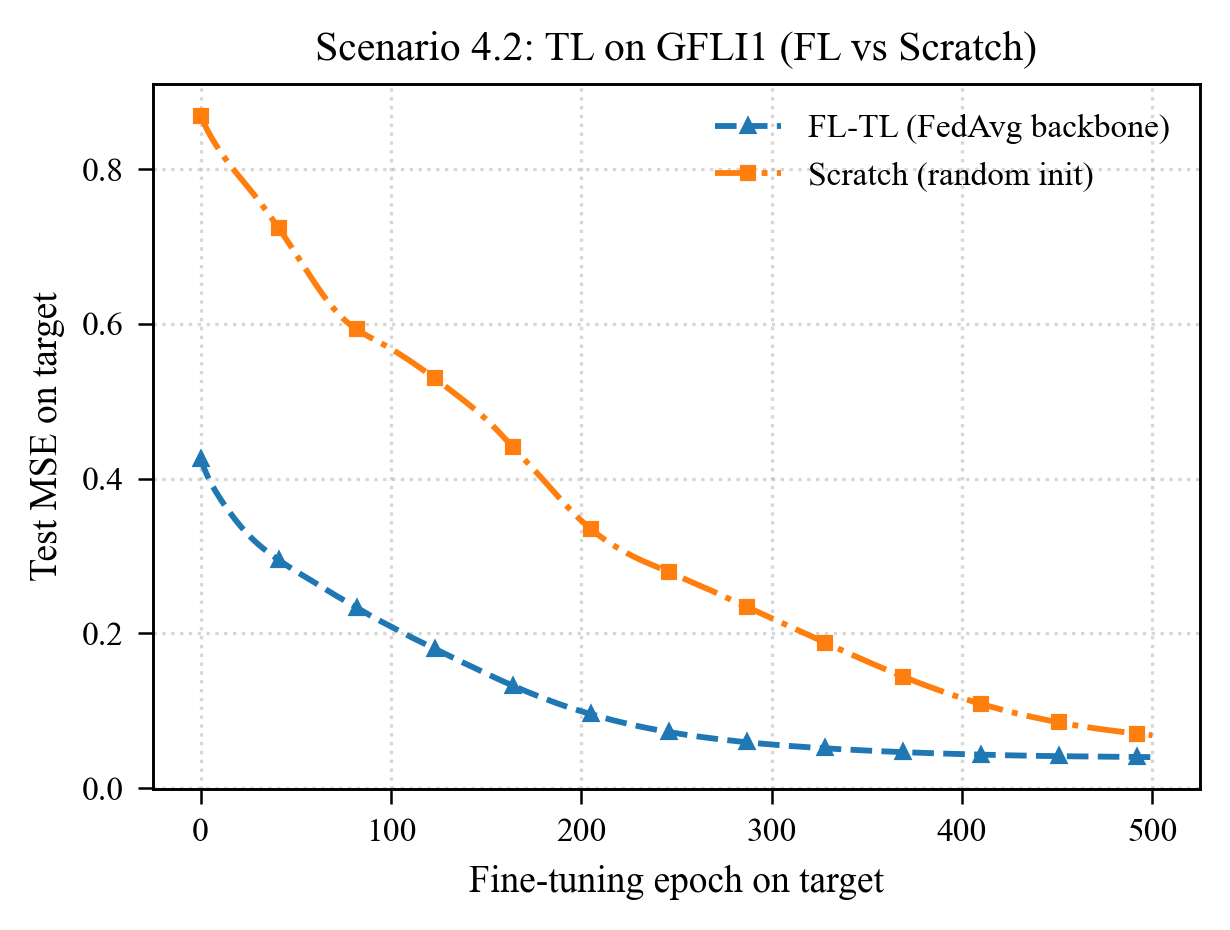

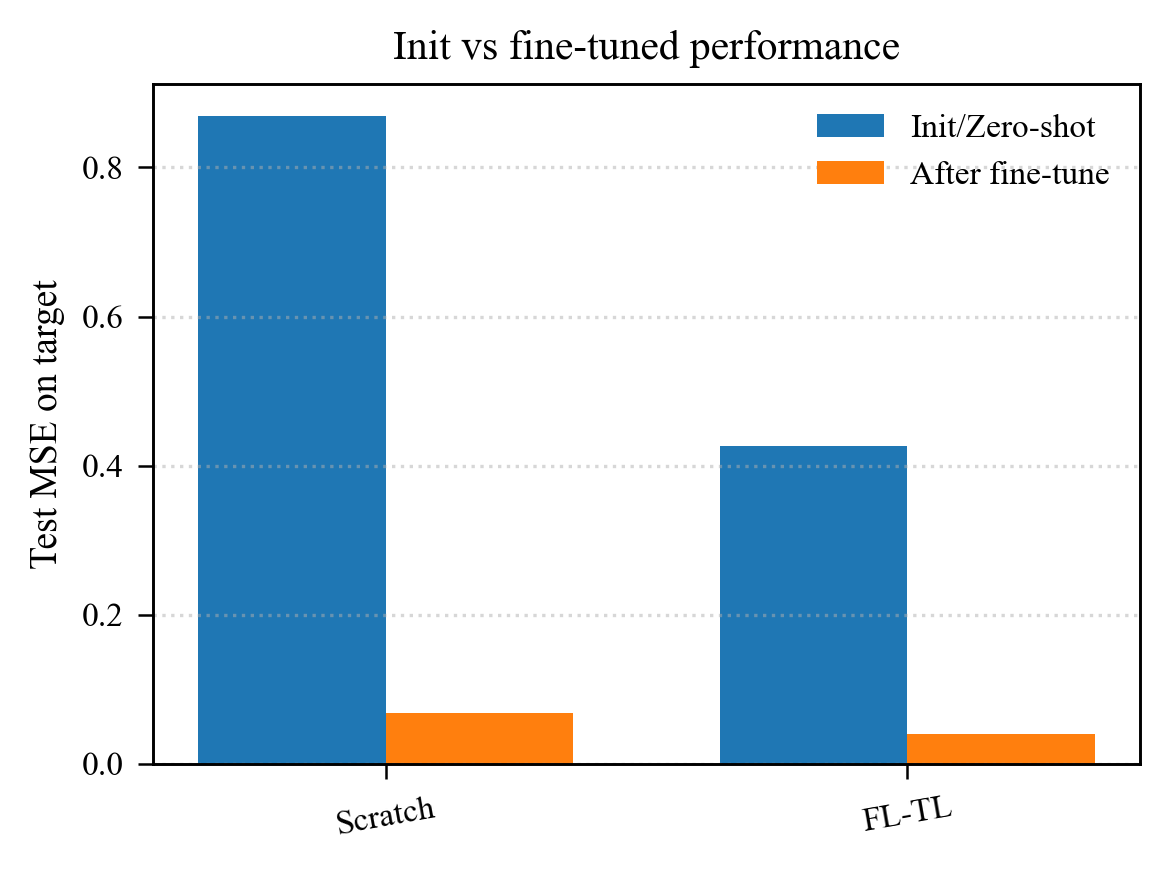

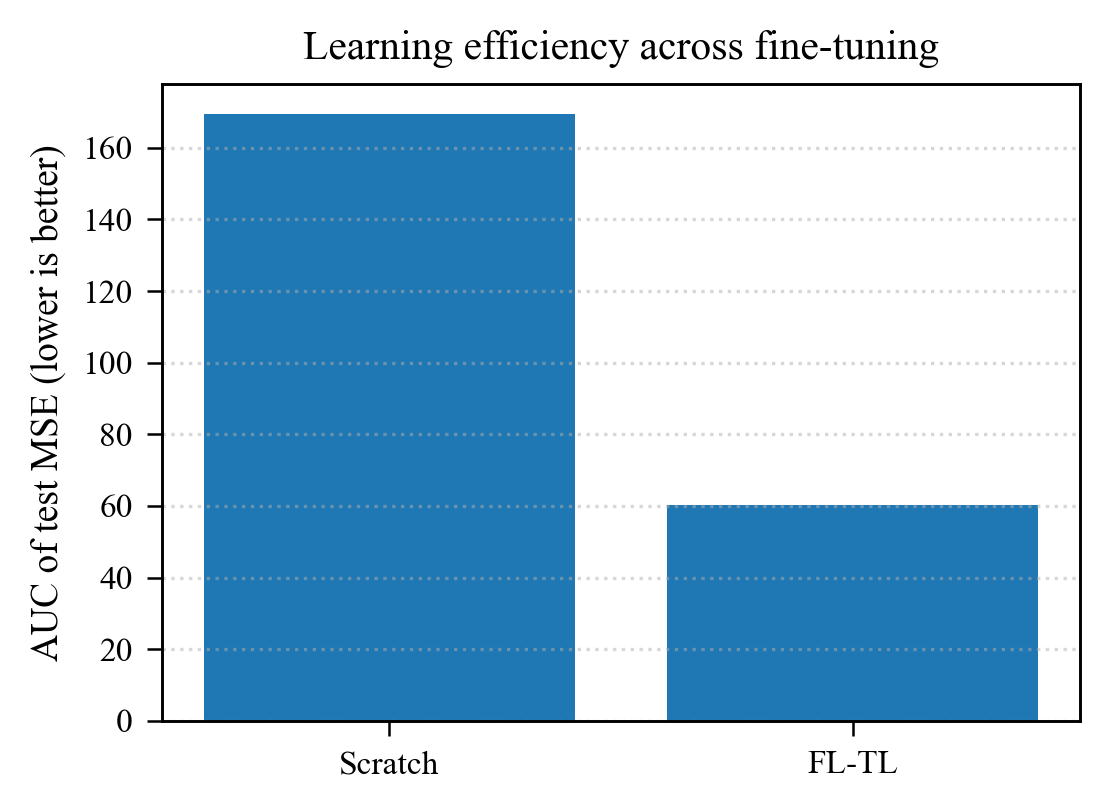


Scenario 4.2 summary (Central TL removed)
TARGET_IBR: gfli1
SOURCE_IBRS: ['gfli2', 'gfli3', 'gfli4', 'gfli5', 'gfli6', 'gfli7', 'gfli8', 'gfli9']
----------------------------------------------------------------------
Init/Zero-shot test MSE | Scratch: 8.6852e-01 | FL-TL: 4.2587e-01
Final test MSE          | Scratch: 6.8352e-02 | FL-TL: 4.0157e-02
AUC (lower better)      | Scratch: 1.6936e+02 | FL-TL: 6.0380e+01
Best final test MSE: FL-TL (4.0157e-02)


In [200]:
# ============================================================
# Cell 10 — Plot TL comparison (FL-TL vs Scratch)
# ============================================================

# Matplotlib style (IEEE-like)
mpl.rcParams.update(
    {
        "figure.dpi": 300,
        "savefig.dpi": 600,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.linewidth": 0.7,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "lines.linewidth": 1.4,
    }
)

def save_figure(fig, filename: str) -> None:
    fig.tight_layout()
    fig.savefig(filename, bbox_inches="tight")
    if filename.endswith(".pdf"):
        fig.savefig(filename.replace(".pdf", ".svg"), bbox_inches="tight")

def build_curve(zero_val, fine_tune_curve):
    curve = np.asarray(fine_tune_curve, dtype=float)
    return np.insert(curve, 0, float(zero_val))

fl_curve = build_curve(zero_fl, te_ft_fl)
sc_curve = build_curve(zero_sc, te_ft_sc)
epochs_axis = np.arange(len(fl_curve))

# sanity
assert len(fl_curve) == len(sc_curve)

final_mse = {"FL-TL": fl_curve[-1], "Scratch": sc_curve[-1]}
zero_shot = {"FL-TL": fl_curve[0],  "Scratch": sc_curve[0]}
auc = {"FL-TL": float(np.trapz(fl_curve, epochs_axis)),
       "Scratch": float(np.trapz(sc_curve, epochs_axis))}

# Figure 1: curves
fig1, ax1 = plt.subplots(figsize=(4.2, 3.2))
ax1.plot(epochs_axis, fl_curve, label="FL-TL (FedAvg backbone)", linestyle="--", marker="^",
         markevery=max(len(epochs_axis)//12, 1), markersize=3)
ax1.plot(epochs_axis, sc_curve, label="Scratch (random init)", linestyle="-.", marker="s",
         markevery=max(len(epochs_axis)//12, 1), markersize=3)
ax1.set_xlabel("Fine-tuning epoch on target")
ax1.set_ylabel("Test MSE on target")
ax1.set_title(f"Scenario 4.2: TL on {TARGET_IBR.upper()} (FL vs Scratch)")
ax1.grid(True, ls=":", alpha=0.5)
ax1.legend(loc="upper right", frameon=False)
save_figure(fig1, f"fig_tl_{TARGET_IBR}_curves.pdf")
plt.show()

# Figure 2: zero-shot vs final
labels = ["Scratch", "FL-TL"]
zero_vals  = [zero_shot["Scratch"], zero_shot["FL-TL"]]
final_vals = [final_mse["Scratch"], final_mse["FL-TL"]]

x = np.arange(len(labels))
w = 0.36
fig2, ax2 = plt.subplots(figsize=(4.0, 3.0))
ax2.bar(x - w/2, zero_vals,  w, label="Init/Zero-shot")
ax2.bar(x + w/2, final_vals, w, label="After fine-tune")
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=10)
ax2.set_ylabel("Test MSE on target")
ax2.set_title("Init vs fine-tuned performance")
ax2.grid(True, axis="y", ls=":", alpha=0.5)
ax2.legend(loc="upper right", frameon=False)
save_figure(fig2, f"fig_tl_{TARGET_IBR}_zero_vs_final.pdf")
plt.show()

# Figure 3: AUC
fig3, ax3 = plt.subplots(figsize=(3.8, 2.8))
ax3.bar(["Scratch", "FL-TL"], [auc["Scratch"], auc["FL-TL"]])
ax3.set_ylabel("AUC of test MSE (lower is better)")
ax3.set_title("Learning efficiency across fine-tuning")
ax3.grid(True, axis="y", ls=":", alpha=0.5)
save_figure(fig3, f"fig_tl_{TARGET_IBR}_auc.pdf")
plt.show()

print("\n" + "="*70)
print("Scenario 4.2 summary (Central TL removed)")
print("="*70)
print("TARGET_IBR:", TARGET_IBR)
print("SOURCE_IBRS:", SOURCE_IBRS)
print("-"*70)
print(f"Init/Zero-shot test MSE | Scratch: {zero_shot['Scratch']:.4e} | FL-TL: {zero_shot['FL-TL']:.4e}")
print(f"Final test MSE          | Scratch: {final_mse['Scratch']:.4e} | FL-TL: {final_mse['FL-TL']:.4e}")
print(f"AUC (lower better)      | Scratch: {auc['Scratch']:.4e} | FL-TL: {auc['FL-TL']:.4e}")
best = min(final_mse, key=final_mse.get)
print(f"Best final test MSE: {best} ({final_mse[best]:.4e})")
print("="*70)



===== Data efficiency: limited target labels (FL-TL vs Scratch) =====
[DataEff-Scratch-k-shot] Init/Zero-shot test MSE = 8.7881e-01
[DataEff-Scratch-k-shot] Epoch 001 | train MSE=1.0245e+00 | test MSE=8.7661e-01
[DataEff-Scratch-k-shot] Epoch 002 | train MSE=1.0200e+00 | test MSE=8.7449e-01
[DataEff-Scratch-k-shot] Epoch 003 | train MSE=1.0157e+00 | test MSE=8.7237e-01
[DataEff-Scratch-k-shot] Epoch 004 | train MSE=1.0115e+00 | test MSE=8.7034e-01
[DataEff-Scratch-k-shot] Epoch 005 | train MSE=1.0075e+00 | test MSE=8.6839e-01
[DataEff-Scratch-k-shot] Epoch 006 | train MSE=1.0037e+00 | test MSE=8.6654e-01
[DataEff-Scratch-k-shot] Epoch 007 | train MSE=9.9993e-01 | test MSE=8.6476e-01
[DataEff-Scratch-k-shot] Epoch 008 | train MSE=9.9634e-01 | test MSE=8.6309e-01
[DataEff-Scratch-k-shot] Epoch 009 | train MSE=9.9277e-01 | test MSE=8.6152e-01
[DataEff-Scratch-k-shot] Epoch 010 | train MSE=9.8944e-01 | test MSE=8.6002e-01
[DataEff-Scratch-k-shot] Epoch 011 | train MSE=9.8612e-01 | test MS

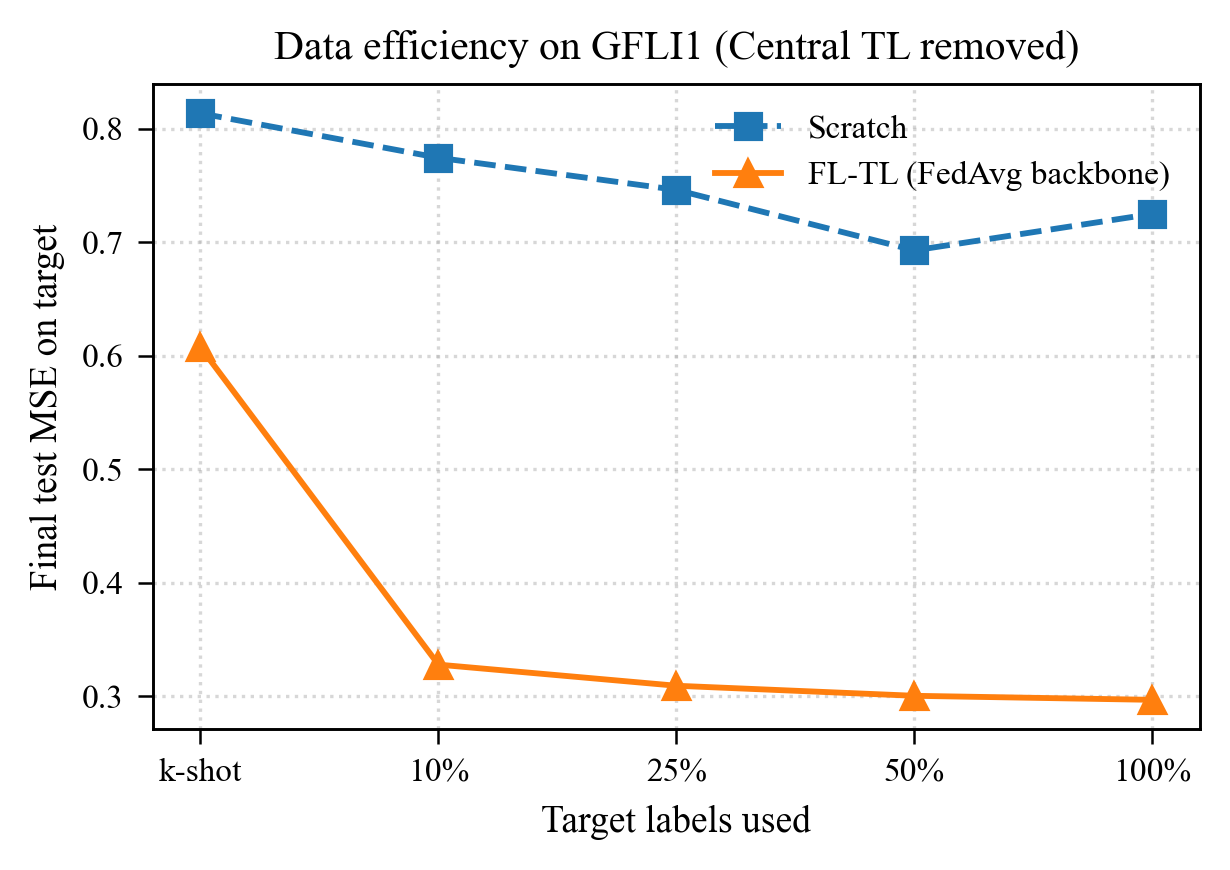

C:\Users\ACER\AppData\Local\Temp\ipykernel_24716\4254930265.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
C:\Users\ACER\AppData\Local\Temp\ipykernel_24716\4254930265.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


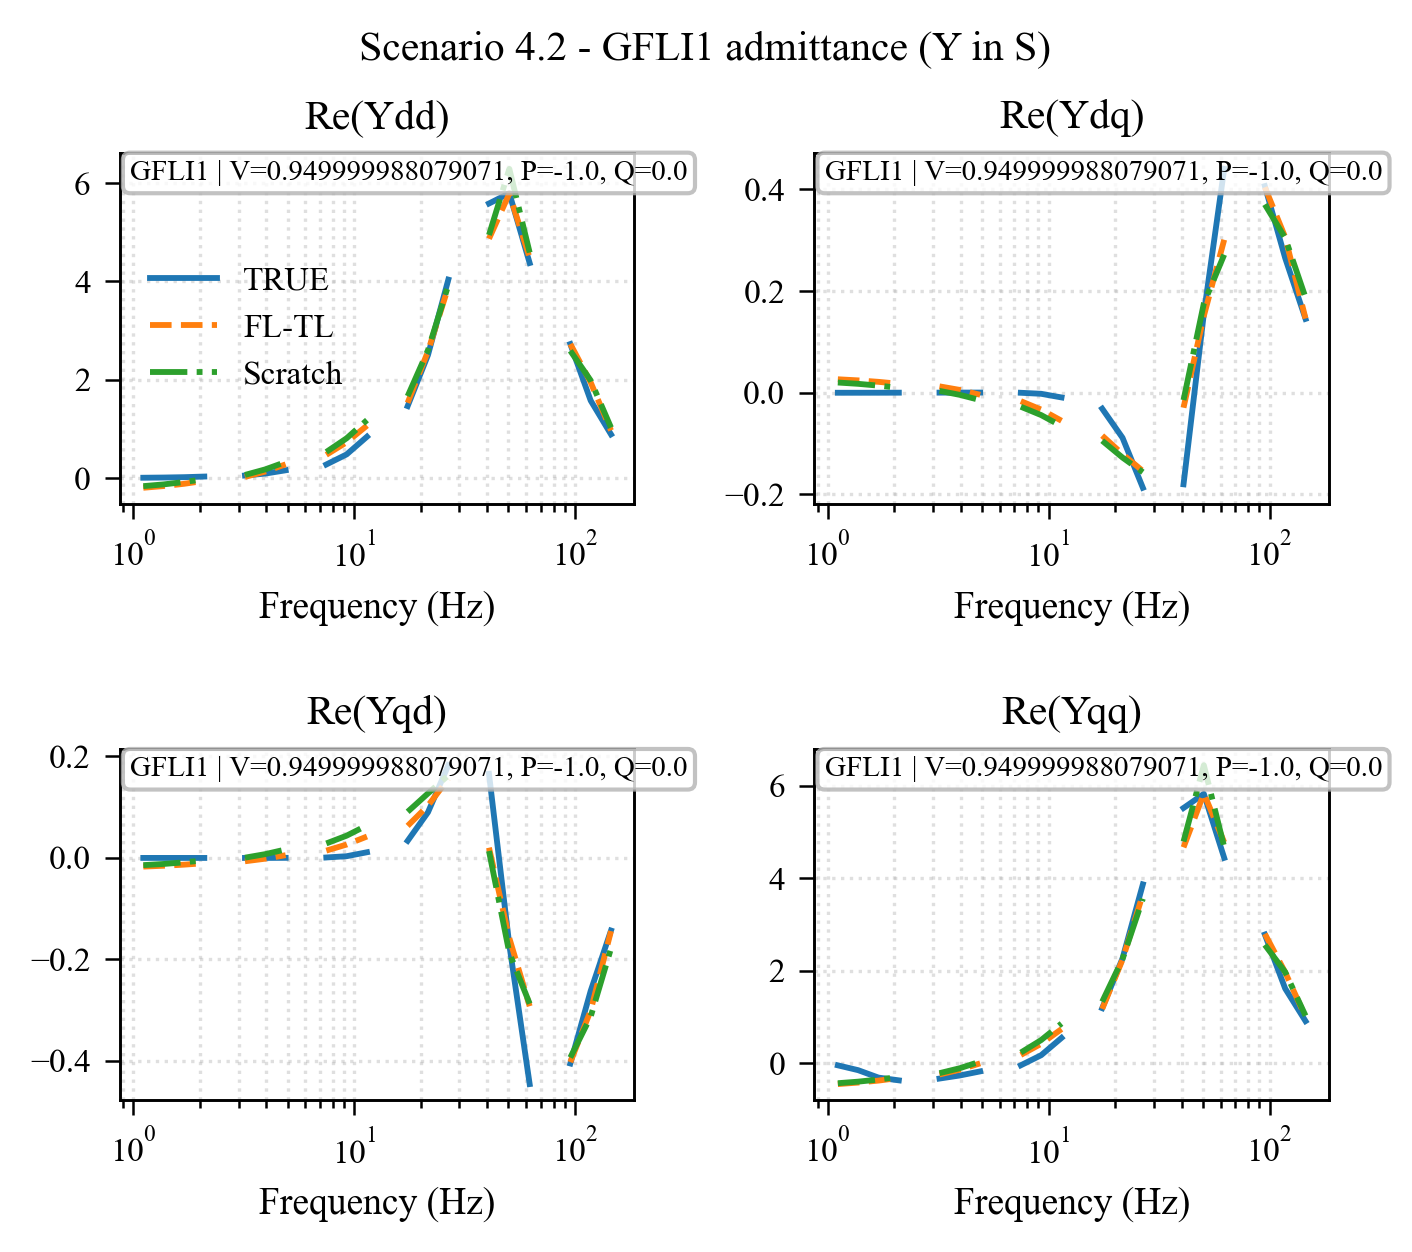

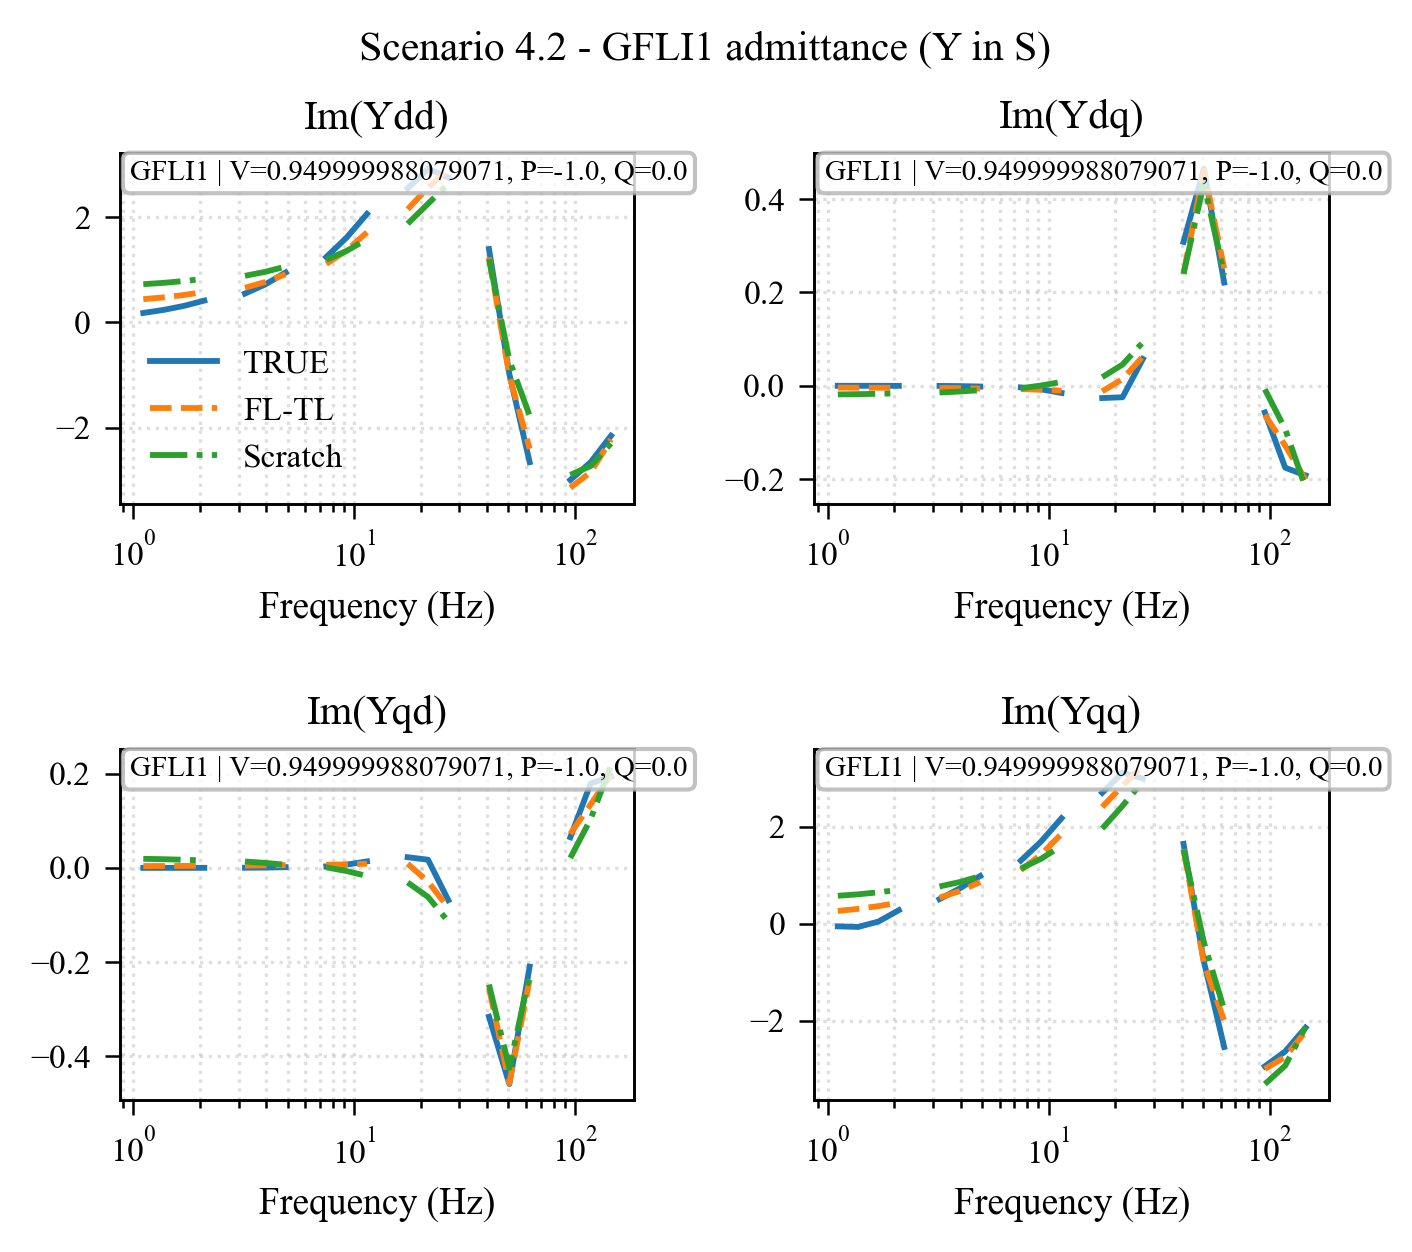

In [201]:
# ============================================================
# Cell 11 — Optional: Data efficiency (k-shot + fractions) FL-TL vs Scratch
# ============================================================

ENABLE_DATA_EFFICIENCY = True
K_SHOT = 12
DATA_EFF_FRACS = [0.10, 0.25, 0.50, 1.0]
DATA_EFF_SEED = 42
DATA_EFF_EPOCHS = min(EPOCHS_FT_TARGET, 40)

def subset_dataset(ds: TensorDataset, frac=None, k=None, seed=42):
    assert (frac is not None) ^ (k is not None)
    n_total = len(ds)
    if frac is not None:
        n = max(1, min(n_total, int(np.ceil(n_total * frac))))
    else:
        n = max(1, min(n_total, int(k)))

    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(n_total, generator=g)[:n]
    tensors = [t[idx] for t in ds.tensors]
    return TensorDataset(*tensors), n, n/n_total

if ENABLE_DATA_EFFICIENCY:
    specs = [("k-shot", {"k": K_SHOT})] + [(f"{int(fr*100)}%", {"frac": fr}) for fr in DATA_EFF_FRACS]
    rows = []

    print("\n===== Data efficiency: limited target labels (FL-TL vs Scratch) =====")
    for i, (label, cfg) in enumerate(specs):
        subset, n_used, frac_used = subset_dataset(train_target, frac=cfg.get("frac"), k=cfg.get("k"),
                                                   seed=DATA_EFF_SEED + i)
        bs = min(BATCH_SIZE, len(subset))

        # Scratch
        _, z_sc, _, te_sc = fine_tune(
            base_state_dict_cpu=None,
            train_ds=subset,
            test_ds=test_target,
            epochs=DATA_EFF_EPOCHS,
            batch_size=bs,
            lr=1e-3,
            tag=f"DataEff-Scratch-{label}",
        )
        final_sc = te_sc[-1]

        # FL-TL
        _, z_fl, _, te_fl = fine_tune(
            base_state_dict_cpu=fl_global_state,
            train_ds=subset,
            test_ds=test_target,
            epochs=DATA_EFF_EPOCHS,
            batch_size=bs,
            lr=1e-3,
            tag=f"DataEff-FLTL-{label}",
        )
        final_fl = te_fl[-1]

        rows.append({
            "label": label, "n_used": n_used, "frac_used": frac_used,
            "final_scratch": final_sc, "final_fltl": final_fl
        })

    labels_de = [r["label"] for r in rows]
    scratch_vals = [r["final_scratch"] for r in rows]
    fltl_vals    = [r["final_fltl"] for r in rows]

    fig_de, ax_de = plt.subplots(figsize=(4.2, 3.0))
    ax_de.plot(labels_de, scratch_vals, marker="s", linestyle="--", label="Scratch")
    ax_de.plot(labels_de, fltl_vals, marker="^", linestyle="-", label="FL-TL (FedAvg backbone)")
    ax_de.set_xlabel("Target labels used")
    ax_de.set_ylabel("Final test MSE on target")
    ax_de.set_title(f"Data efficiency on {TARGET_IBR.upper()} (Central TL removed)")
    ax_de.grid(True, ls=":", alpha=0.5)
    ax_de.legend(loc="upper right", frameon=False)
    save_figure(fig_de, f"fig_tl_{TARGET_IBR}_data_efficiency.pdf")
    plt.show()


# ============================================================
# Cell 12 — Optional: Admittance plot (TRUE vs FL-TL vs Scratch)
# ============================================================

ZB_BASE_OHM = 95.2  # pu -> Siemens conversion (Y_S = Y_pu / Zbase)

components = [
    ("Ydd", 0, 1),
    ("Ydq", 2, 3),
    ("Yqd", 4, 5),
    ("Yqq", 6, 7),
]

def build_freq_bins(freq_pool, nbins=25):
    f_all = np.asarray(freq_pool)
    f_all = f_all[np.isfinite(f_all)]
    f_all = f_all[f_all > 0]
    f_min, f_max = f_all.min(), f_all.max()
    edges = np.logspace(np.log10(f_min), np.log10(f_max), nbins + 1)
    centers = np.sqrt(edges[:-1] * edges[1:])
    return edges, centers

def reduce_by_bin(f, y, edges):
    f = np.asarray(f); y = np.asarray(y)
    out = np.full(len(edges) - 1, np.nan, dtype=float)
    for i in range(len(edges) - 1):
        m = (f >= edges[i]) & (f < edges[i+1])
        if np.any(m):
            out[i] = np.median(y[m])
    return out

def plot_admittance_true_vs_models(model_fltl, model_scratch, test_ds_scaled, target_ibr, nbins=25):
    Xs = test_ds_scaled.tensors[0].cpu().numpy()
    Ys = test_ds_scaled.tensors[1].cpu().numpy()

    X_phys = X_scaler.inverse_transform(Xs)
    Y_true = Y_scaler.inverse_transform(Ys)

    with torch.no_grad():
        Yp_fl = model_fltl(test_ds_scaled.tensors[0].to(device)).cpu().numpy()
        Yp_sc = model_scratch(test_ds_scaled.tensors[0].to(device)).cpu().numpy()

    Yp_fl = Y_scaler.inverse_transform(Yp_fl)
    Yp_sc = Y_scaler.inverse_transform(Yp_sc)

    # pu -> Siemens
    Y_true = Y_true / ZB_BASE_OHM
    Yp_fl  = Yp_fl  / ZB_BASE_OHM
    Yp_sc  = Yp_sc  / ZB_BASE_OHM

    f = X_phys[:, 3]
    f_pool = f.copy()
    edges, centers = build_freq_bins(f_pool, nbins=nbins)

    # (Optional) owner selection by rounding V,P,Q to avoid float-group explosion
    V = X_phys[:, 0]; P = X_phys[:, 1]; Q = X_phys[:, 2]
    df = pd.DataFrame({
        "V": np.round(V, 3),
        "P": np.round(P, 3),
        "Q": np.round(Q, 3),
        "idx": np.arange(len(f)),
    })

    # pick one “owner” with enough points, else all
    chosen = None
    for (v,p,q), grp in df.groupby(["V","P","Q"]):
        if len(grp) >= 20:
            chosen = (v,p,q, grp["idx"].values)
            break
    if chosen is None:
        chosen = (None, None, None, np.arange(len(f)))

    v,p,q, idxs = chosen
    owner_tag = f"{target_ibr.upper()} | all points" if v is None else f"{target_ibr.upper()} | V={v}, P={p}, Q={q}"

    fig_re, axes_re = plt.subplots(2, 2, figsize=(5.2, 4.1), gridspec_kw={"hspace": 0.7, "wspace": 0.35})
    fig_im, axes_im = plt.subplots(2, 2, figsize=(5.2, 4.1), gridspec_kw={"hspace": 0.7, "wspace": 0.35})
    axes_re = axes_re.ravel()
    axes_im = axes_im.ravel()

    for comp_i, (name, re_i, im_i) in enumerate(components):
        axr = axes_re[comp_i]
        axi = axes_im[comp_i]

        curve_re_true = reduce_by_bin(f[idxs], Y_true[idxs, re_i], edges)
        curve_re_fl   = reduce_by_bin(f[idxs], Yp_fl[idxs,  re_i], edges)
        curve_re_sc   = reduce_by_bin(f[idxs], Yp_sc[idxs,  re_i], edges)

        curve_im_true = reduce_by_bin(f[idxs], Y_true[idxs, im_i], edges)
        curve_im_fl   = reduce_by_bin(f[idxs], Yp_fl[idxs,  im_i], edges)
        curve_im_sc   = reduce_by_bin(f[idxs], Yp_sc[idxs,  im_i], edges)

        axr.semilogx(centers, curve_re_true, label="TRUE")
        axr.semilogx(centers, curve_re_fl,   label="FL-TL", linestyle="--")
        axr.semilogx(centers, curve_re_sc,   label="Scratch", linestyle="-.")
        axr.grid(True, which="both", ls=":", alpha=0.4)
        axr.set_title(f"Re({name})")
        axr.text(0.02, 0.98, owner_tag, transform=axr.transAxes, va="top", ha="left",
                 fontsize=7, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.8))

        axi.semilogx(centers, curve_im_true, label="TRUE")
        axi.semilogx(centers, curve_im_fl,   label="FL-TL", linestyle="--")
        axi.semilogx(centers, curve_im_sc,   label="Scratch", linestyle="-.")
        axi.grid(True, which="both", ls=":", alpha=0.4)
        axi.set_title(f"Im({name})")
        axi.text(0.02, 0.98, owner_tag, transform=axi.transAxes, va="top", ha="left",
                 fontsize=7, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.8))

    for ax in axes_re: ax.set_xlabel("Frequency (Hz)")
    for ax in axes_im: ax.set_xlabel("Frequency (Hz)")

    axes_re[0].legend(loc="best", frameon=False)
    axes_im[0].legend(loc="best", frameon=False)

    fig_re.suptitle(f"Scenario 4.2 - {target_ibr.upper()} admittance (Y in S)", fontsize=10)
    fig_im.suptitle(f"Scenario 4.2 - {target_ibr.upper()} admittance (Y in S)", fontsize=10)

    save_figure(fig_re, f"fig_tl_{target_ibr}_admittance_re.pdf")
    save_figure(fig_im, f"fig_tl_{target_ibr}_admittance_im.pdf")
    plt.show()

# call
plot_admittance_true_vs_models(
    model_fltl=model_ft_fl,
    model_scratch=model_ft_scratch,
    test_ds_scaled=test_target,
    target_ibr=TARGET_IBR,
    nbins=25,
)